**1. Title and objective**

TPMS AI POC — EV Tire Pressure Monitoring System

Goal:
Build a simple machine-learning model that predicts whether a vehicle is likely to have a TPMS (Tire Pressure Monitoring System) alert based on EV sensor data.

Dataset:
Four user-driving profiles:
   - rare_user
   - heavy_user
   - daily_user
   - moderate_user

Models evaluated:
   1. Logistic Regression
   2. Random Forest
   3. XGBoost

Selected model:
 Random Forest

Important:
 Tire_Pressure is used ONLY to create the target label. It is NOT used as an ML input feature. This prevents target leakage.


**2. Import libraries and load datasets**

In [54]:
#LOAD DATASETS

import os
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Machine-learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier


# Dataset location
DATA_DIR = "../data/raw/dataset1"

# Check available files
print("Dataset files:")
print(os.listdir(DATA_DIR))


# Load the four user-profile datasets
rare = pd.read_csv(f"{DATA_DIR}/rare_user.csv")
heavy = pd.read_csv(f"{DATA_DIR}/heavy_user.csv")
daily = pd.read_csv(f"{DATA_DIR}/daily_user.csv")
moderate = pd.read_csv(f"{DATA_DIR}/moderate_user.csv")


print("\nDataset shapes:")
print("Rare    :", rare.shape)
print("Heavy   :", heavy.shape)
print("Daily   :", daily.shape)
print("Moderate:", moderate.shape)


Dataset files:
['rare_user.csv', 'heavy_user.csv', 'daily_user.csv', 'moderate_user.csv']

Dataset shapes:
Rare    : (43800, 12)
Heavy   : (43800, 12)
Daily   : (43800, 12)
Moderate: (43800, 12)


**3. Combine datasets**

In [55]:
#COMBINE DATASETS

# Add a label identifying the type of user profile.
# This is useful for understanding the source of each row.
rare["user_type"] = "rare"
heavy["user_type"] = "heavy"
daily["user_type"] = "daily"
moderate["user_type"] = "moderate"


# Combine all four datasets into one DataFrame.
df = pd.concat(
    [rare, heavy, daily, moderate],
    ignore_index=True
)


print("Combined dataset shape:", df.shape)

print("\nRows by user type:")
print(df["user_type"].value_counts())


Combined dataset shape: (175200, 13)

Rows by user type:
user_type
rare        43800
heavy       43800
daily       43800
moderate    43800
Name: count, dtype: int64


**4. Basic data understanding**

In [56]:
#BASIC DATA UNDERSTANDING

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
display(df.describe())

print("\nTotal rows   :", len(df))
print("Total columns:", len(df.columns))


Columns:
['Unnamed: 0', 'SOC', 'SOH', 'Charging_Cycles', 'Battery_Temp', 'Motor_RPM', 'Motor_Torque', 'Motor_Temp', 'Brake_Pad_Wear', 'Charging_Voltage', 'Tire_Pressure', 'DTC', 'user_type']

Data types:
Unnamed: 0              str
SOC                 float64
SOH                 float64
Charging_Cycles       int64
Battery_Temp        float64
Motor_RPM           float64
Motor_Torque        float64
Motor_Temp          float64
Brake_Pad_Wear      float64
Charging_Voltage      int64
Tire_Pressure       float64
DTC                     str
user_type               str
dtype: object

Missing values:
Unnamed: 0          0
SOC                 0
SOH                 0
Charging_Cycles     0
Battery_Temp        0
Motor_RPM           0
Motor_Torque        0
Motor_Temp          0
Brake_Pad_Wear      0
Charging_Voltage    0
Tire_Pressure       0
DTC                 0
user_type           0
dtype: int64

Basic statistics:


,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Charging_Voltage,Tire_Pressure
count,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000
mean,56.389522,94.294021,186.454595,32.465710,551.114754,110.222951,71.857564,67.439094,320.000000,28.561853
std,22.071815,4.059302,142.896816,6.080449,1087.768197,217.553639,6.632244,20.654193,80.000228,2.076328
min,20.000000,81.861306,0.000000,21.687029,0.000000,0.000000,57.184178,29.985945,240.000000,23.239785
25%,37.533136,91.708946,69.000000,29.065473,0.000000,0.000000,68.252920,49.423387,240.000000,26.774076
50%,54.925774,94.730919,152.000000,30.684599,0.000000,0.000000,70.451232,68.506263,320.000000,28.557223
75%,74.073419,97.796721,286.000000,32.928672,0.000000,0.000000,72.913011,86.137540,400.000000,30.325350
max,100.000000,99.999816,601.000000,65.834883,4746.911143,949.382229,111.533018,100.000000,400.000000,34.995836



Total rows   : 175200
Total columns: 13


**5. Create TPMS target**

In [57]:
#CREATE TPMS TARGET

# TPMS alert is triggered when tire pressure falls below the selected threshold.

# Tire_Pressure is used to create the target label. It will NOT be given directly to the ML model.

TPMS_THRESHOLD = 25.1

df["TPMS_alert"] = (
    df["Tire_Pressure"] < TPMS_THRESHOLD
).astype(int)


print("TPMS threshold:", TPMS_THRESHOLD)

print("\nTarget distribution:")
print(df["TPMS_alert"].value_counts())

print("\nTarget percentage:")
print(
    df["TPMS_alert"]
    .value_counts(normalize=True)
    .mul(100)
)


print("\nExample:")
display(
    df[["Tire_Pressure", "TPMS_alert"]].head(10)
)


TPMS threshold: 25.1

Target distribution:
TPMS_alert
0    172571
1      2629
Name: count, dtype: int64

Target percentage:
TPMS_alert
0    98.499429
1     1.500571
Name: proportion, dtype: float64

Example:


,Tire_Pressure,TPMS_alert
0,34.995836,0
1,34.991402,0
2,34.987041,0
3,34.982546,0
4,34.977305,0
5,34.971602,0
6,34.966091,0
7,34.960225,0
8,34.955566,0
9,34.951448,0


**6. Define ML features**

In [58]:
#DEFINE ML FEATURES

# These are the 8 numeric sensor features used by the model.

# Tire_Pressure is intentionally excluded because it was used to create the TPMS_alert target.

# DTC is also excluded because it contains categorical/text values such as "P0MR", which require separate encoding.
# For this POC we keep the model simple and use numeric sensors.

FEATURES = [
    "SOC",
    "SOH",
    "Battery_Temp",
    "Motor_RPM",
    "Motor_Torque",
    "Motor_Temp",
    "Brake_Pad_Wear",
    "Charging_Voltage"
]

TARGET = "TPMS_alert"


X = df[FEATURES]
y = df[TARGET]


print("Features used by ML model:")
print(FEATURES)

print("\nNumber of features:", len(FEATURES))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget counts:")
print(y.value_counts())


Features used by ML model:
['SOC', 'SOH', 'Battery_Temp', 'Motor_RPM', 'Motor_Torque', 'Motor_Temp', 'Brake_Pad_Wear', 'Charging_Voltage']

Number of features: 8
X shape: (175200, 8)
y shape: (175200,)

Target counts:
TPMS_alert
0    172571
1      2629
Name: count, dtype: int64


**7. Train/test split**

In [59]:
#TRAIN / TEST SPLIT

# Stratification keeps approximately the same percentage of TPMS alerts in both training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


Training rows: 140160
Testing rows : 35040

Training target distribution:
TPMS_alert
0    138057
1      2103
Name: count, dtype: int64

Testing target distribution:
TPMS_alert
0    34514
1      526
Name: count, dtype: int64


**8. Train the three models**

In [60]:
#TRAIN ML MODELS

# Logistic Regression

# class_weight="balanced" gives additional importance to the minority TPMS-alert class.

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained.")


# Random Forest

# Random Forest is expected to perform well with nonlinear relationships between vehicle sensor values and TPMS alerts.

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained.")


# XGBoost

# Because TPMS alerts are rare, use scale_pos_weight to give more importance to the positive class.

positive_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=positive_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained.")

print("\nAll three models trained successfully.")


Logistic Regression trained.
Random Forest trained.
XGBoost trained.

All three models trained successfully.


**9. Evaluate all models**

In [61]:
# MODEL EVALUATION

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

evaluation_results = []


for name, model in models.items():

    # Generate predictions on unseen test data
    predictions = model.predict(X_test)

    # Calculate classification metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))


# Convert results into a DataFrame
results_df = pd.DataFrame(evaluation_results)

print("\nModel comparison:")
display(results_df)



Logistic Regression
Accuracy : 0.5412
Precision: 0.0160
Recall   : 0.4886
F1 Score : 0.0310

Confusion Matrix:
[[18706 15808]
 [  269   257]]

Random Forest
Accuracy : 0.9904
Precision: 0.8406
Recall   : 0.4411
F1 Score : 0.5786

Confusion Matrix:
[[34470    44]
 [  294   232]]

XGBoost
Accuracy : 0.7446
Precision: 0.0450
Recall   : 0.7928
F1 Score : 0.0852

Confusion Matrix:
[[25673  8841]
 [  109   417]]

Model comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.541182,0.015998,0.488593,0.030981
1,Random Forest,0.990354,0.840580,0.441065,0.578554
2,XGBoost,0.744578,0.045042,0.792776,0.085241


**10. Model comparison chart**

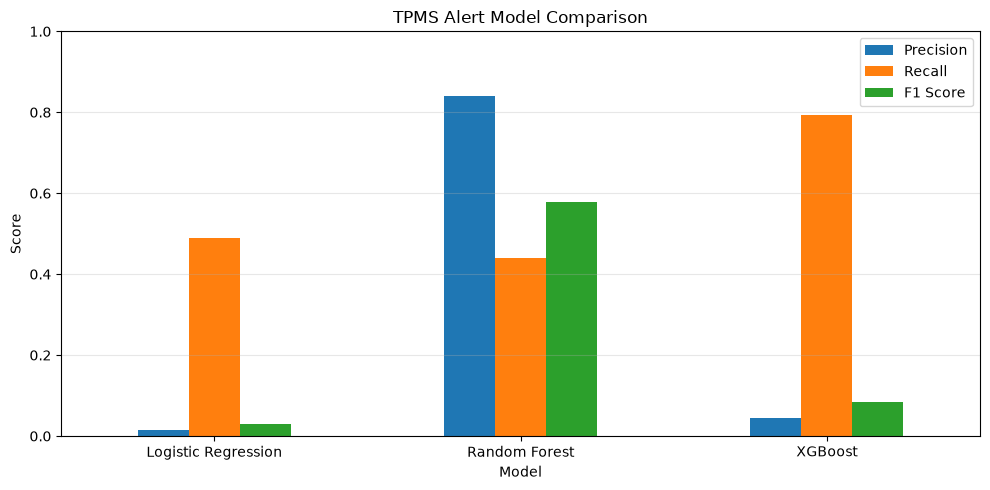

In [62]:
#MODEL COMPARISON CHART

# F1, precision and recall are more informative than accuracy for this problem because TPMS alerts are rare.

results_plot = results_df.set_index("Model")

results_plot[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("TPMS Alert Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


**11. Select the best model**

In [63]:
# SELECT BEST MODEL

# F1 Score balances precision and recall.
# For this POC, the model with the highest F1 score is selected.

best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_model = models[best_model_name]


print("Best model based on F1 Score:")
print(best_model_name)


Best model based on F1 Score:
Random Forest


**12. Confusion matrix for Random Forest**

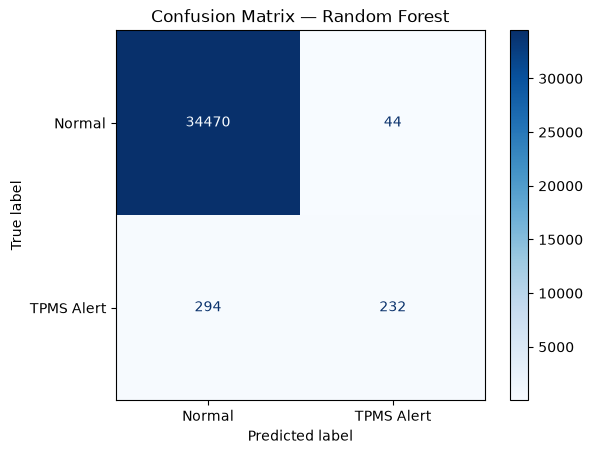

In [64]:
# BEST MODEL CONFUSION MATRIX

best_predictions = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=["Normal", "TPMS Alert"],
    cmap="Blues"
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


**13. Save the selected model**

In [65]:
# SAVE SELECTED MODEL

MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)


# Save the Random Forest model used by the dashboard
MODEL_PATH = f"{MODEL_DIR}/random_forest_model.pkl"

joblib.dump(
    rf_model,
    MODEL_PATH
)

print("Random Forest model saved:")
print(MODEL_PATH)


Random Forest model saved:
../models/random_forest_model.pkl


**14. Save the feature list**

In [66]:
# SAVE FEATURE LIST

FEATURE_PATH = f"{MODEL_DIR}/features.json"

with open(FEATURE_PATH, "w") as f:
    json.dump(FEATURES, f, indent=2)


print("Feature list saved:")
print(FEATURE_PATH)

print("\nFeatures:")
print(FEATURES)


Feature list saved:
../models/features.json

Features:
['SOC', 'SOH', 'Battery_Temp', 'Motor_RPM', 'Motor_Torque', 'Motor_Temp', 'Brake_Pad_Wear', 'Charging_Voltage']


**15. Verify the saved model**

In [67]:
# VERIFY SAVED MODEL

# Reload the model from disk to make sure the dashboard will be able to load the same model.

loaded_model = joblib.load(MODEL_PATH)

print("Model loaded successfully.")
print("Model type:", type(loaded_model).__name__)
print("Number of features:", loaded_model.n_features_in_)

print("\nFeatures expected by model:")
print(loaded_model.feature_names_in_)

print("\nSaved features:")
print(FEATURES)


Model loaded successfully.
Model type: RandomForestClassifier
Number of features: 8

Features expected by model:
['SOC' 'SOH' 'Battery_Temp' 'Motor_RPM' 'Motor_Torque' 'Motor_Temp'
 'Brake_Pad_Wear' 'Charging_Voltage']

Saved features:
['SOC', 'SOH', 'Battery_Temp', 'Motor_RPM', 'Motor_Torque', 'Motor_Temp', 'Brake_Pad_Wear', 'Charging_Voltage']


**16. Test Random Forest predictions**

In [68]:
# ANALYZE RANDOM FOREST PREDICTIONS

# Generate predictions using the saved model.
rf_predictions = loaded_model.predict(X_test)


# Create a table containing:
#   - sensor values
#   - actual TPMS status
#   - model prediction
prediction_results = X_test.copy()

prediction_results["Actual_TPMS"] = y_test.values
prediction_results["Predicted_TPMS"] = rf_predictions


# Prediction distribution

print("Predicted class counts:")
print(pd.Series(rf_predictions).value_counts())

print("\nActual class counts:")
print(y_test.value_counts())


# Correctly detected TPMS alerts

correct_alerts = prediction_results[
    (prediction_results["Actual_TPMS"] == 1) &
    (prediction_results["Predicted_TPMS"] == 1)
]


print("\nCorrectly predicted TPMS alerts:",
      len(correct_alerts))


print("\nExample correctly predicted alerts:")
display(correct_alerts.head(10))


Predicted class counts:
0    34764
1      276
Name: count, dtype: int64

Actual class counts:
TPMS_alert
0    34514
1      526
Name: count, dtype: int64

Correctly predicted TPMS alerts: 232

Example correctly predicted alerts:


,SOC,SOH,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Charging_Voltage,Actual_TPMS,Predicted_TPMS
92292,46.552032,93.038829,30.362576,0.0,0.0,72.389812,83.330629,240,1,1
90212,37.212833,96.718352,30.687390,0.0,0.0,71.427975,90.898774,240,1,1
14476,80.000000,94.945238,29.096979,0.0,0.0,69.764868,49.551912,240,1,1
69452,47.825755,96.782476,31.665018,0.0,0.0,66.149882,91.069376,400,1,1
79527,57.754602,93.081947,29.571258,0.0,0.0,67.629565,33.525933,400,1,1
109660,28.157508,98.029314,29.584346,0.0,0.0,72.815612,96.345883,240,1,1
114325,29.906308,96.671917,31.247193,0.0,0.0,70.128351,81.411668,240,1,1
38575,80.000000,92.377852,30.045092,0.0,0.0,67.767710,32.140298,240,1,1
75602,36.802253,94.522723,30.891433,0.0,0.0,72.487409,55.861672,400,1,1
174027,50.326311,87.273299,27.377212,0.0,0.0,71.577426,87.382138,400,1,1


**17. Final POC summary**

In [69]:
# FINAL POC SUMMARY

best_row = results_df[
    results_df["Model"] == best_model_name
].iloc[0]


# Calculate final alert statistics
actual_alerts = int((y_test == 1).sum())

correctly_detected = int(
    (
        (y_test == 1) &
        (best_predictions == 1)
    ).sum()
)

false_negatives = int(
    (
        (y_test == 1) &
        (best_predictions == 0)
    ).sum()
)

false_positives = int(
    (
        (y_test == 0) &
        (best_predictions == 1)
    ).sum()
)


print("=" * 55)
print("TPMS AI POC — FINAL SUMMARY")
print("=" * 55)

print("\nObjective:")
print("Predict TPMS alerts using EV sensor data.")

print("\nSelected Model:")
print(best_model_name)

print("\nTest Performance:")
print(f"Accuracy : {best_row['Accuracy']:.2%}")
print(f"Precision: {best_row['Precision']:.2%}")
print(f"Recall   : {best_row['Recall']:.2%}")
print(f"F1 Score : {best_row['F1 Score']:.2%}")

print("\nTPMS Alert Detection:")
print("Actual TPMS alerts     :", actual_alerts)
print("Correctly detected     :", correctly_detected)
print("False negatives        :", false_negatives)
print("False positives        :", false_positives)

print("\nML Features:")
for feature in FEATURES:
    print("-", feature)

print("\nDashboard:")
print("dashboard/app.py")

print("\nPOC STATUS: COMPLETE")


TPMS AI POC — FINAL SUMMARY

Objective:
Predict TPMS alerts using EV sensor data.

Selected Model:
Random Forest

Test Performance:
Accuracy : 99.04%
Precision: 84.06%
Recall   : 44.11%
F1 Score : 57.86%

TPMS Alert Detection:
Actual TPMS alerts     : 526
Correctly detected     : 232
False negatives        : 294
False positives        : 44

ML Features:
- SOC
- SOH
- Battery_Temp
- Motor_RPM
- Motor_Torque
- Motor_Temp
- Brake_Pad_Wear
- Charging_Voltage

Dashboard:
dashboard/app.py

POC STATUS: COMPLETE
